# 01 — Data Exploration

Load the Monza 2024 Race session, verify available telemetry channels, and confirm DRS encoding, brake channel type, and lateral acceleration availability.

In [11]:
import sys
sys.path.insert(0, '..')

import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fastf1.Cache.enable_cache('../cache')
fastf1.plotting.setup_mpl()

## Load session

In [12]:
session = fastf1.get_session(2024, 'Monza', 'R')
session.load(telemetry=True, weather=True)
print('Drivers:', list(session.drivers))

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']


Drivers: ['16', '81', '4', '55', '44', '1', '63', '11', '23', '20', '14', '43', '3', '31', '10', '77', '27', '24', '18', '22']


## Pick a driver and inspect a lap's telemetry channels

In [13]:
# Use the race winner for initial exploration
winner_abbr = session.results.iloc[0]['Abbreviation']
print('Winner:', winner_abbr)

laps = session.laps.pick_drivers(winner_abbr)
# Pick a representative mid-race lap
lap = laps.iloc[len(laps)//2]
tel = lap.get_telemetry()

print('\nTelemetry columns:')
print(tel.columns.tolist())
print('\nShape:', tel.shape)
tel.head()

Winner: LEC

Telemetry columns:
['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source', 'Distance', 'RelativeDistance', 'Status', 'X', 'Y', 'Z']

Shape: (632, 18)


,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,Distance,RelativeDistance,Status,X,Y,Z
2,2024-09-01 13:40:39.512,0 days 01:32:55.593000,,147.713056,0 days 00:00:00,11330.499981,317.449999,8,99.0,False,0,interpolation,0.020732,0.000004,OnTrack,-1378.266965,-729.972166,1871.149300
3,2024-09-01 13:40:39.649,0 days 01:32:55.730000,,147.713056,0 days 00:00:00.137000,11371.599962,318.819999,8,99.0,False,0,pos,12.162709,0.002119,OnTrack,-1359.000000,-508.000000,1872.000000
4,2024-09-01 13:40:39.667,0 days 01:32:55.748000,,147.713056,0 days 00:00:00.155000,11377.000000,319.000000,8,99.0,False,0,car,13.759722,0.002397,OnTrack,-1356.847896,-483.221094,1872.106897
5,2024-09-01 13:40:39.868,0 days 01:32:55.949000,4,147.713056,0 days 00:00:00.356000,11429.000000,320.000000,8,99.0,False,0,car,31.626389,0.005510,OnTrack,-1338.762702,-275.273136,1873.222618
6,2024-09-01 13:40:40.049,0 days 01:32:56.130000,4,148.014722,0 days 00:00:00.537000,11446.345827,321.508333,8,99.0,False,0,pos,47.798605,0.008327,OnTrack,-1328.000000,-152.000000,1874.000000


## Verify DRS encoding

DRS unique values: [np.int64(0)]
DRS dtype: int64

DRS > 10 means open (FastF1 convention: 10=detection, 12=enabled, 14=open)


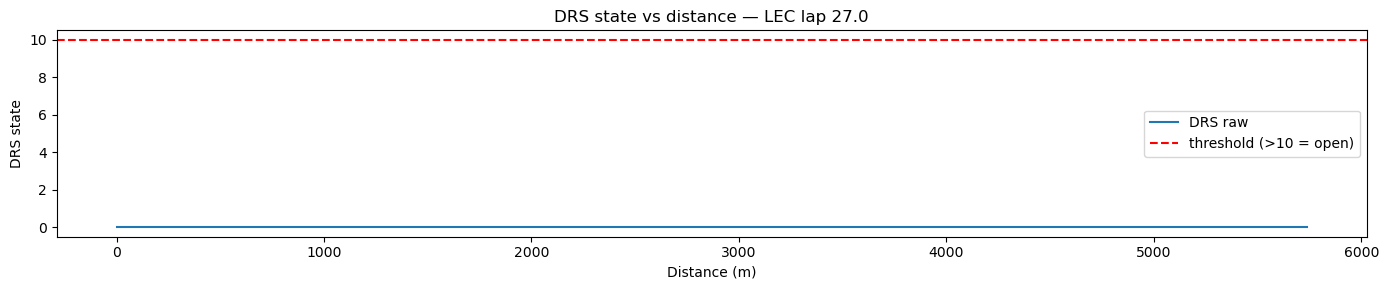

In [14]:
print('DRS unique values:', sorted(tel['DRS'].unique()))
print('DRS dtype:', tel['DRS'].dtype)
print('\nDRS > 10 means open (FastF1 convention: 10=detection, 12=enabled, 14=open)')

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(tel['Distance'], tel['DRS'], label='DRS raw')
ax.axhline(10, color='r', linestyle='--', label='threshold (>10 = open)')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('DRS state')
ax.set_title(f'DRS state vs distance — {winner_abbr} lap {lap["LapNumber"]}')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/01_drs_encoding.png', dpi=150)
plt.show()

## Verify brake channel

In [15]:
print('Brake dtype:', tel['Brake'].dtype)
print('Brake unique (first 10):', tel['Brake'].unique()[:10])
print('Throttle dtype:', tel['Throttle'].dtype)
print('Speed dtype:', tel['Speed'].dtype)

Brake dtype: bool
Brake unique (first 10): [False  True]
Throttle dtype: float64
Speed dtype: float64


## Check for lateral acceleration channel

In [16]:
lat_candidates = ['lateral_acceleration', 'LateralAcceleration', 'lateral_g', 'LatG', 'lat_g', 'ay', 'Ay']
found = [c for c in lat_candidates if c in tel.columns]
print('Direct lateral g channels found:', found)

pos_channels = [c for c in tel.columns if c in ['X', 'Y', 'Z']]
print('Position channels found:', pos_channels)

if not found:
    print('\nNo direct lateral g — will compute from X/Y GPS position in Phase 4.')
    if 'X' in tel.columns and 'Y' in tel.columns:
        print('GPS position available — computed lat g is feasible.')
    else:
        print('WARNING: No GPS position either — ClA estimation will need an alternative.')

Direct lateral g channels found: []
Position channels found: ['X', 'Y', 'Z']

No direct lateral g — will compute from X/Y GPS position in Phase 4.
GPS position available — computed lat g is feasible.


## Weather data check

In [17]:
weather = session.weather_data
print('Weather columns:', weather.columns.tolist())
print(weather[['AirTemp', 'Pressure', 'Humidity']].describe())

Weather columns: ['Time', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed']
          AirTemp    Pressure    Humidity
count  133.000000  133.000000  133.000000
mean    33.101504  993.228571   32.285714
std      0.554183    0.334748    1.448988
min     32.200000  992.700000   30.000000
25%     32.500000  993.000000   31.000000
50%     33.200000  993.100000   32.000000
75%     33.600000  993.500000   33.000000
max     34.100000  993.900000   38.000000


## Full telemetry overview for a single lap

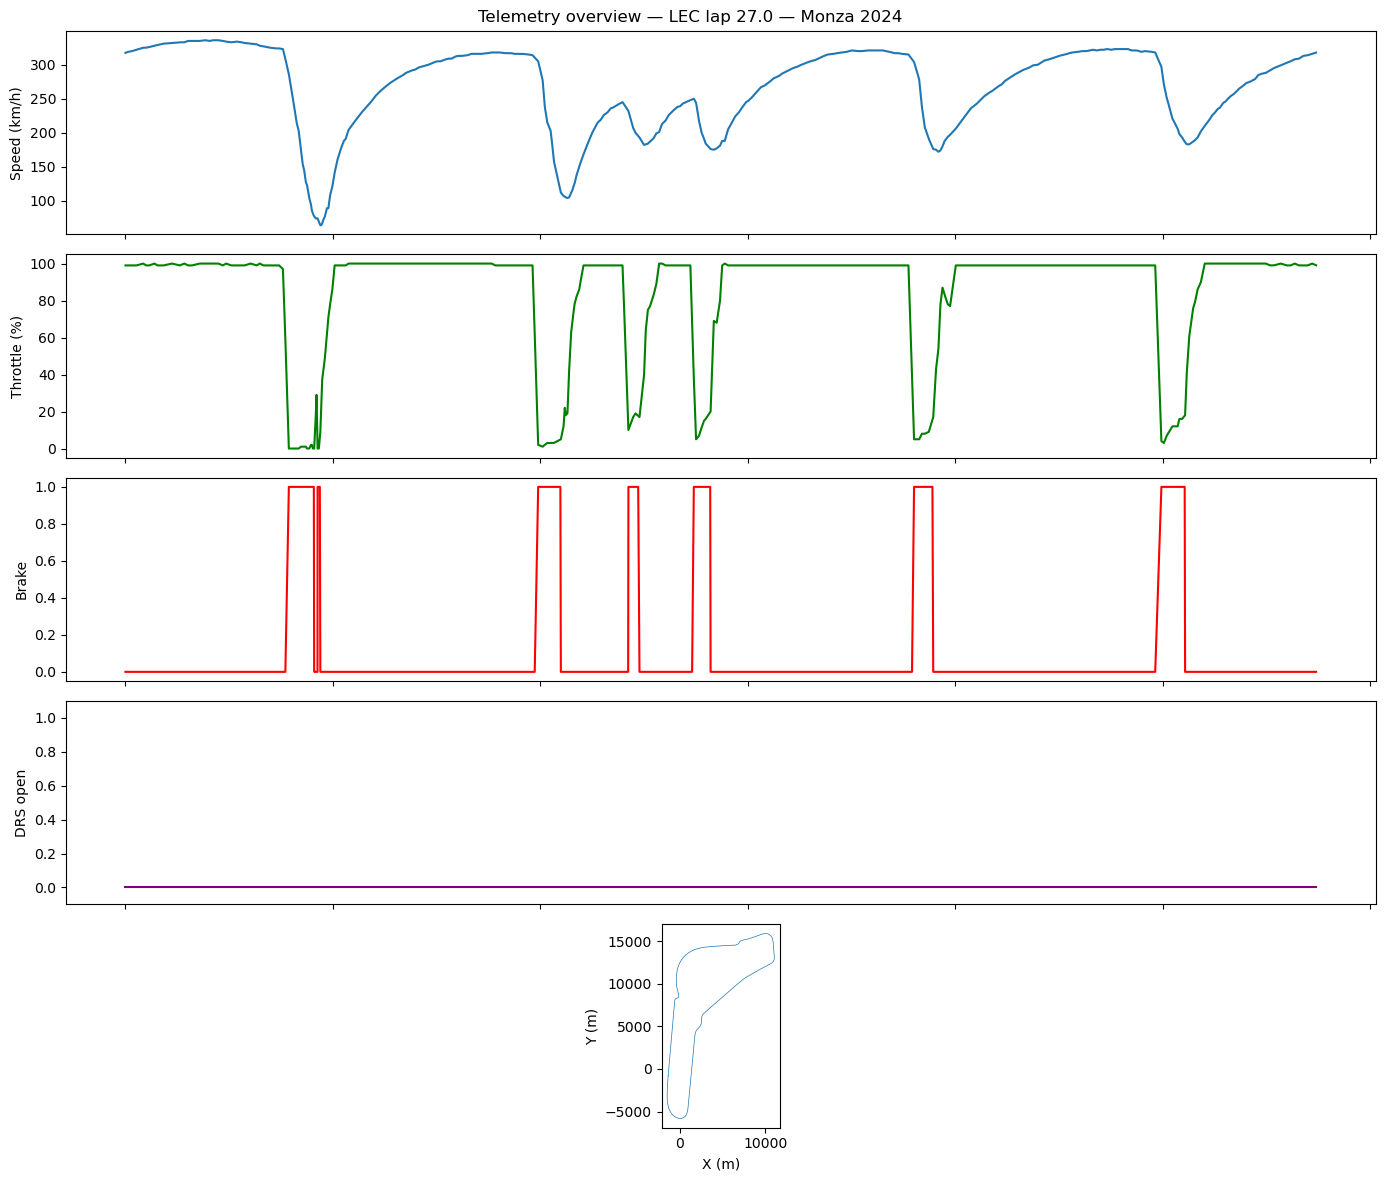

In [18]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

axes[0].plot(tel['Distance'], tel['Speed'])
axes[0].set_ylabel('Speed (km/h)')

axes[1].plot(tel['Distance'], tel['Throttle'], color='g')
axes[1].set_ylabel('Throttle (%)')

axes[2].plot(tel['Distance'], tel['Brake'].astype(float), color='r')
axes[2].set_ylabel('Brake')

axes[3].plot(tel['Distance'], (tel['DRS'] > 10).astype(int), color='purple')
axes[3].set_ylabel('DRS open')
axes[3].set_ylim(-0.1, 1.1)

if 'X' in tel.columns:
    axes[4].set_visible(False)
    # Replace with GPS track
    axes[4] = fig.add_subplot(5, 1, 5)
    axes[4].plot(tel['X'], tel['Y'], lw=0.5)
    axes[4].set_aspect('equal')
    axes[4].set_xlabel('X (m)')
    axes[4].set_ylabel('Y (m)')
else:
    axes[4].set_ylabel('(no GPS)')
    axes[4].set_xlabel('Distance (m)')

fig.suptitle(f'Telemetry overview — {winner_abbr} lap {lap["LapNumber"]} — Monza 2024')
plt.tight_layout()
plt.savefig('../results/figures/01_telemetry_overview.png', dpi=150)
plt.show()

## Summary

Document what you found:
- DRS encoding confirmed / needs adjustment
- Brake channel: bool / 0-100 float
- Lateral g: direct channel present / must compute from GPS
- Weather: AirTemp, Pressure available

Carry forward to notebook 02.